# Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.linalg import LinAlgError


from sklearn.metrics import mean_squared_error as mse

from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

from prophet import Prophet
from math import sqrt

import plotly.graph_objs as go
import plotly.offline as py

# Data

In [2]:
# Load Data set
data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv",
                   parse_dates=['Month'],
                   index_col='Month',
                   date_format='%Y-%m')  # %m as no(1,2,..,12), %b as name(jan, feb..,dec))
df = data.copy()

# data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv")
# df = data.copy()
# df['Month'] = pd.to_datetime(df['Month'])
# df.set_index('Month', inplace=True)

# Find And Fill Missing Values
df.isna().sum()

# Find Outliers For Single Columns 
def find_outlier(data):
    
    outliers = []
    
    mean = data.mean()
    std = data.std()

    lower_limit = mean - 3 * std
    upper_limit = mean + 3 * std

    for value in data:
        if value < lower_limit or value > upper_limit:
            outliers.append(value)

    return outliers
    
# Find Outliers of TotalSpend 
print('Before : ', find_outlier(df['#Passengers']), 'Length : ', len(find_outlier(df['#Passengers'])))

Before :  [] Length :  0


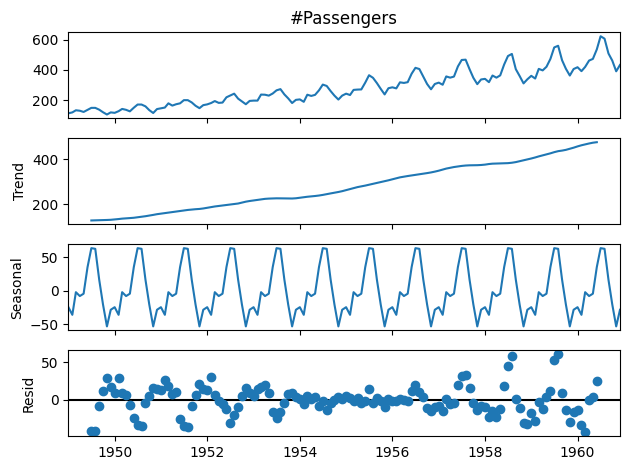

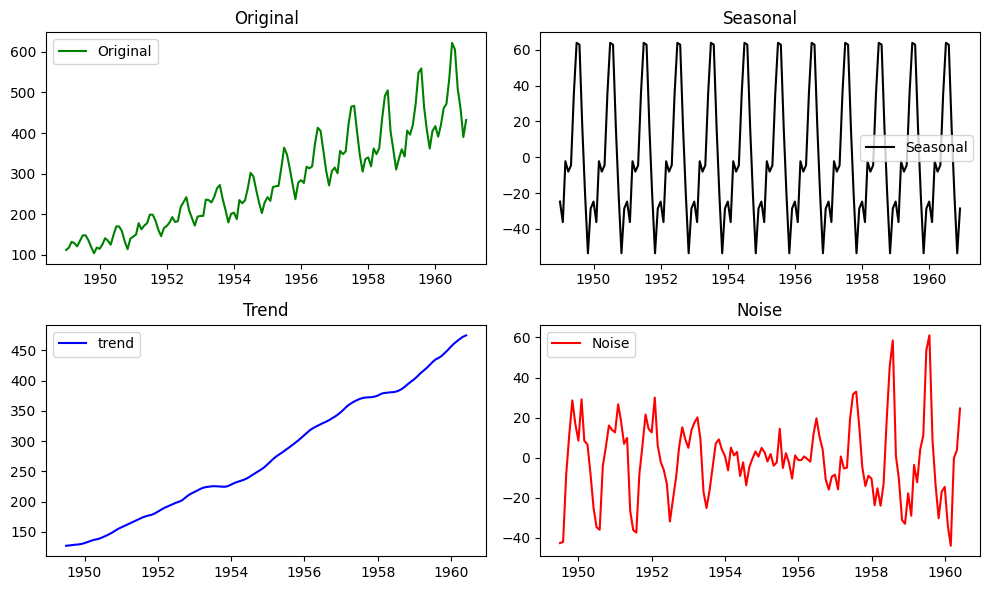

Statistic Value : 0.8153688792060482
P-Value : 0.991880243437641
Lag Used : 13
Observations : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : 996.692930839019


In [3]:
# Seasonality 
Raw_Seasonality = sd(df['#Passengers'], model='Multiplicative')
Raw_Seasonality.plot();


# Seasonality By Subplots
trend = Raw_Seasonality.trend
Noise = Raw_Seasonality.resid
Seasonal = Raw_Seasonality.seasonal

# Plot Subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Original
axes[0, 0].plot(df, label=['Original'], color='Green')
axes[0, 0].set_title('Original')
axes[0, 0].legend(loc='best')

# Trend
axes[1, 0].plot(trend, label=['trend'], color='Blue')
axes[1, 0].set_title('Trend')
axes[1, 0].legend(loc='best')

# Noise
axes[1, 1].plot(Noise, label=['Noise'], color='Red')
axes[1, 1].set_title('Noise')
axes[1, 1].legend(loc='best')

# Seasonal
axes[0, 1].plot(Seasonal, label=['Seasonal'], color='black')
axes[0, 1].set_title('Seasonal')
axes[0, 1].legend(loc='best')

# Tight Space Ploting
plt.tight_layout()

# Show
plt.show()

# Stationary Test adf(Augmented Dickey Fullers) 
adf_results = adf(df)
Names = ['Statistic Value', 'P-Value', 'Lag Used', 'Observations', 'Critical Values', 'AIC']

for name, result in zip(Names, adf_results):
    print(f'{name} : {result}')

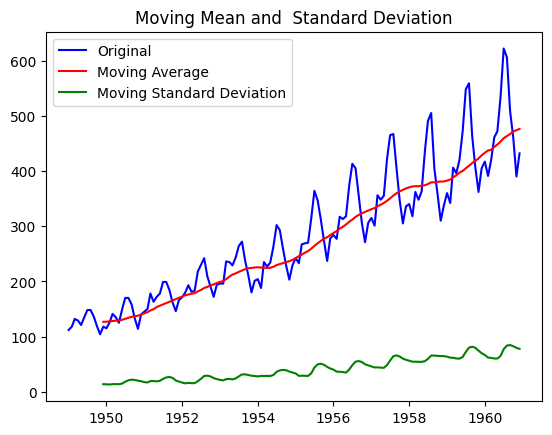

Statistic Value : 0.8153688792060482
P-Value : 0.991880243437641
Lag Used : 13
Observations : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : 996.692930839019


<Figure size 640x480 with 0 Axes>

In [21]:
# Test Stationality
def test_stationality(df):

    # Dermining Rolling Statistics
    mov_avg = pd.Series(df).rolling(window=12).mean()
    mov_std = pd.Series(df).rolling(window=12).std()

    # PLot Rolling Std and Mean with Data
    plt.plot(df, color='blue', label='Original')
    plt.plot(mov_avg, color='red', label='Moving Average')
    plt.plot(mov_std, color='green', label='Moving Standard Deviation')
    plt.legend(loc='best')
    plt.title('Moving Mean and  Standard Deviation')
    plt.show(block=False)
    plt.tight_layout()

    
    adf_results = adf(df)
    Names = ['Statistic Value', 'P-Value', 'Lag Used', 'Observations', 'Critical Values', 'AIC']

    for name, result in zip(Names, adf_results):
        print(f'{name} : {result}')

test_stationality(df['#Passengers'])

# Transformations

### Log Data Transformation

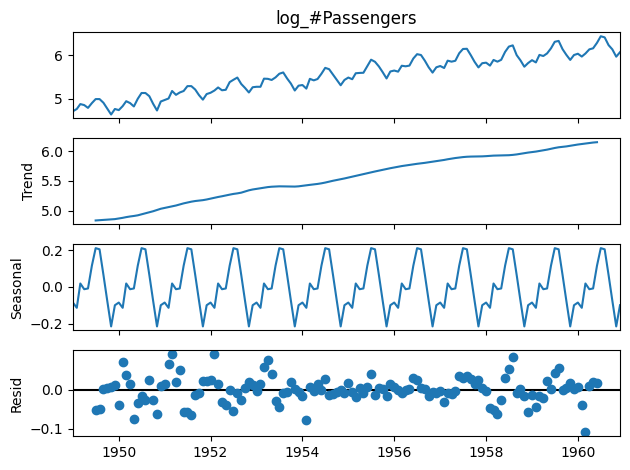

In [22]:
df['log_#Passengers'] = np.log(df['#Passengers'])

# Seasonality Visulization On Log Data
log_Seasonality = sd(df['log_#Passengers'], model='Multiplicative')
log_Seasonality.plot();

# # Stationary Test adf(Augmented Dickey Fullers) 
# adf_results = adf(df['log_#Passengers'])
# Names = ['Statistic Value', 'P-Value', 'Lag Used', 'Observations', 'Critical Values', 'AIC']

# for name, result in zip(Names, adf_results):
#     print(f'{name} : {result}')

# # Skewness 
# print('Skewness of #Passengers and log_#Passengers :\n')
# print(f'#Passengers\t : {df['#Passengers'].skew()}')
# print(f'log_#Passengers  : {df['log_#Passengers'].skew()}')
# print('\n')


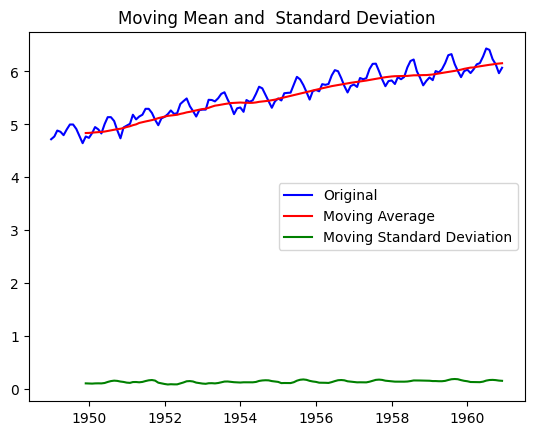

Statistic Value : -1.7170170891069607
P-Value : 0.42236677477039125
Lag Used : 13
Observations : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : -445.3990312497209


<Figure size 640x480 with 0 Axes>

In [23]:
# Stationality Test
test_stationality(df['log_#Passengers'])

### Double Log Data Transformation

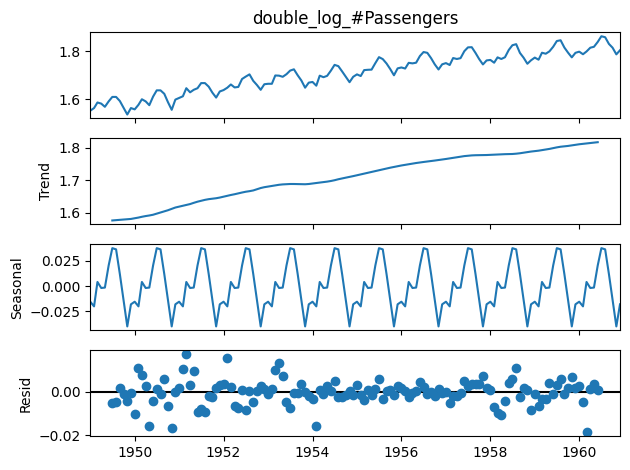

In [41]:
df['double_log_#Passengers'] = np.log(df['log_#Passengers'])

# Seasonality Visulization On Log Data
double_log_Seasonality = sd(df['double_log_#Passengers'], model='addictive')
double_log_Seasonality.plot();

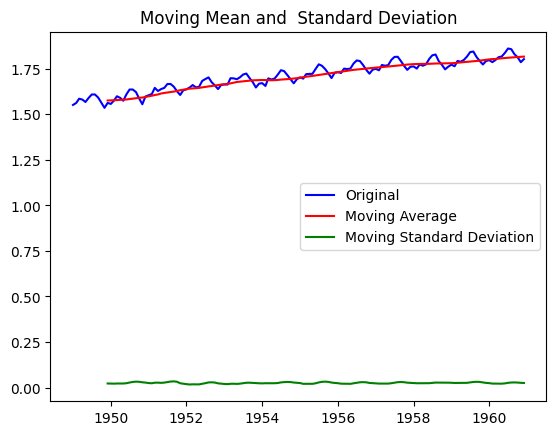

Statistic Value : -2.156027907005565
P-Value : 0.22258989117061473
Lag Used : 13
Observations : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : -879.8116466202985


<Figure size 640x480 with 0 Axes>

In [42]:
# Stationality Test
test_stationality(df['double_log_#Passengers'])

### Log + Moving Average + Diffrencing

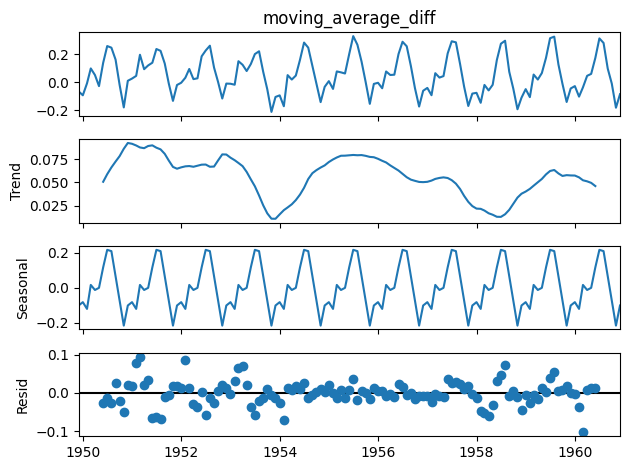

In [46]:
moving_average = pd.Series(df['log_#Passengers']).rolling(window=12).mean()
df['moving_average_diff'] = df['log_#Passengers'] - moving_average

# Seasonality Testing
mov_avg_diff_seasonality = sd(df['moving_average_diff'].dropna(), model='addictive')
mov_avg_diff_seasonality.plot();

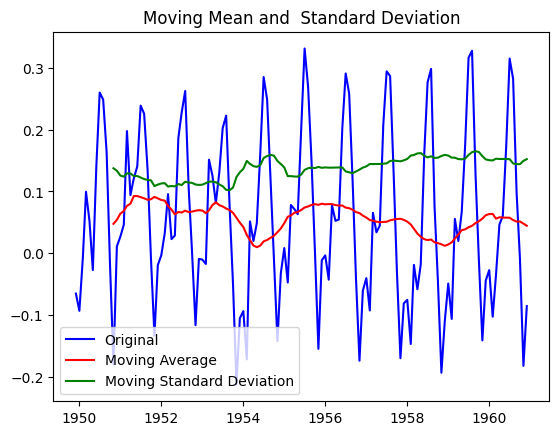

Statistic Value : -3.162907991300869
P-Value : 0.022234630001243157
Lag Used : 13
Observations : 119
Critical Values : {'1%': -3.4865346059036564, '5%': -2.8861509858476264, '10%': -2.579896092790057}
AIC : -436.63269481747034


<Figure size 640x480 with 0 Axes>

In [49]:
# Stationary Testing
test_stationality(df['moving_average_diff'].dropna())

### Exponential Moving Average + Diffrencing

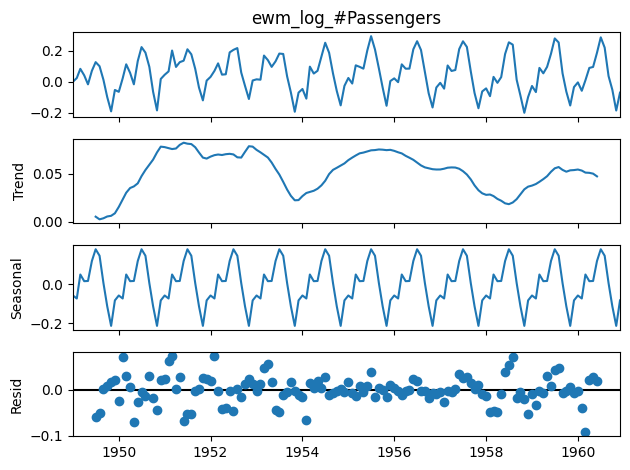

In [54]:
ema = df['log_#Passengers'].ewm(span=12).mean()
df['ewm_log_#Passengers'] = df['log_#Passengers'] - ema

# Test Seasonality 
ema_Seasonality = sd(df['ewm_log_#Passengers'].dropna(), model = 'addictive')
ema_Seasonality.plot();

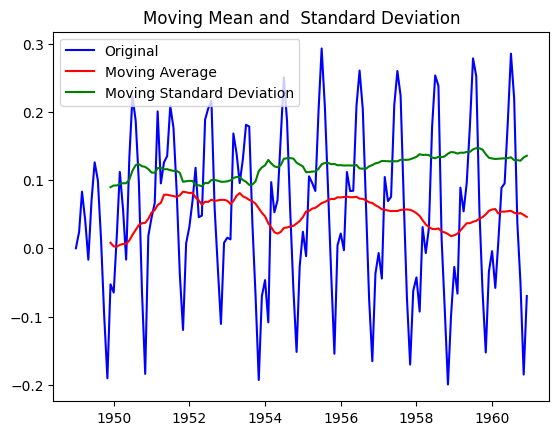

Statistic Value : -3.3105424543208746
P-Value : 0.01441375329697869
Lag Used : 13
Observations : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : -486.11770579662254


<Figure size 640x480 with 0 Axes>

In [55]:
# Stationality Test
test_stationality(df['ewm_log_#Passengers'])

# Inverse Transformations

In [63]:
# Log Inverse (Original)
log_inverse = np.exp(df['#Passengers'])

# Double Log inverse
log_inverse_1 = np.exp(df['double_log_#Passengers'])
log_inverse_last = np.exp(log_inverse_1)

# Log Moving Avg Diff Inverse
first = moving_average + df['moving_average_diff']
log_mov_diff_inv = np.exp(first)

# Log Exp Moving Avg Diff Inverse
firstly = ema + df['ewm_log_#Passengers']
log_exp_mov_diff_inv = np.exp(firstly)

In [ ]:
# Check Skewness of Data
print('Skewness of Following :\n')
print(f'#Passengers\t : {df['#Passengers'].skew()}')
print(f'log_#Passengers  : {df['log_#Passengers'].skew()}')

# Kernal Density Estimator Plot
plt.figure(figsize=(6, 2))
sns.kdeplot(df['#Passengers'])
plt.grid()

print('1949-03-01 :\t', ts['1949-03-01'])
print('1959-03-01 :\t', ts['1959-03-01'])

# Indexing Time Series Array (find Passenger by Index by Month)

# Only March Data on All Years
march_data = ts[ts.index.month == 3]
print(march_data)

# By Library of datetime
ts[datetime(1959, 3, 1)] # No Zero ALlowed

